# From samples to a musical language
## Lesson 02 · ACTAM 2026

Last time, a list of numbers became a sound. We could change its pitch, repeat it and put sounds one after another.

Now we want to do less bookkeeping and say more with our code. We will build three notes, recognise a tune, and introduce functions when repeating the recipe becomes awkward. Then we will give the tune a rhythm and some breathing space.

A second workshop explores a different sound: noise. Can a simple calculation become a percussion instrument?

### How to use this notebook

Run cells from top to bottom with **Shift+Enter**. At each “Your turn”, predict or try something before opening the worked example below it. Restart the kernel and run all cells to check that your work does not depend on old notebook state.

We use the lists, arithmetic, comprehensions and function calls from lesson01. The new tools are function definitions and, in the noise workshop, a stateful `for` loop.

The examples use IPython and Matplotlib from the lesson01 environment. `Audio` is just our convenient renderer for now; later we can send the same sample data to sounddevice. Click a player to listen, starting at a low volume.

## 1. Pick up the thread

What frequency does this list produce? How long will it last?

Count the samples in one period and in the whole sound before running the calculations.

In [1]:
from IPython.display import Audio
from matplotlib import pyplot as plt

sample_rate = 48_000
square = ([-0.15] * 100 + [0.15] * 100) * 100
Audio(square, rate=sample_rate, normalize=False)

In [2]:
samples_per_period = 200
print("Frequency:", sample_rate / samples_per_period, "Hz")
print("Duration:", len(square) / sample_rate, "seconds")

Frequency: 240.0 Hz
Duration: 0.4166666666666667 seconds


One period contains 200 samples. At 48,000 samples per second:

$$T = \frac{200}{48\,000}\text{ s}, \qquad f = \frac{48\,000}{200} = 240\text{ Hz}.$$

The whole list contains 20,000 samples, so it lasts about 0.417 seconds. Period length and total sound length answer different questions.

## 2. Ask for a pitch, a duration and an amplitude

Suppose we want A4, conventionally 440 Hz. Each half-period would need

$$h = \frac{SR}{2f}$$

samples. Our repeated-list recipe needs an integer, so we round. As in lesson01, this introduces a tuning approximation.

In [3]:
amplitude = 0.15
duration = 0.5
f = 440

half_period = round(sample_rate / (2 * f))
period = [-amplitude] * half_period + [amplitude] * half_period
sample_count = round(duration * sample_rate)
repeats = (sample_count + len(period) - 1) // len(period)
wave = (period * repeats)[:sample_count]

print("Requested frequency:", f)
print("Actual frequency:", sample_rate / len(period))
print("Duration:", len(wave) / sample_rate)
Audio(wave, rate=sample_rate, normalize=False)

Requested frequency: 440
Actual frequency: 436.3636363636364
Duration: 0.5


### Two kinds of rounding

Here the period has 110 samples, giving about **436.36 Hz**, rather than exactly 440 Hz. Rounding the half-period is closer than truncating it: `int(48_000 / (2 * 440))` would give a 108-sample period, or about **444.44 Hz**. Neither is exact. This is a limit of our fixed-period recipe, not of digital audio in general.

For duration, we choose a target number of samples. `//` is integer floor division; `(sample_count + len(period) - 1) // len(period)` gives enough whole periods to cover the target. The slice `[:sample_count]` keeps just the required samples. The last period may be incomplete.

This makes duration accurate to the nearest sample. We will keep the pitch approximation visible and improve the oscillator recipe in a future lesson.

### Your turn · Three independent controls

1. Make the sound twice as long without changing its pitch.
2. Restore its duration and make it quieter.
3. Request a pitch one octave higher.

Which quantities change the period? Which change the total number of samples? Check your predictions in the recipe above, then restore its original values.

## 3. Does this sound familiar?

In twelve-tone equal temperament, going up one semitone multiplies frequency by $2^{1/12}$. From A, offsets of 0, 2 and 4 semitones give **A, B and C♯**.

Let's build those three notes with the recipe we already understand.

In [4]:
amplitude = 0.15
duration = 0.5

f = 440
half_period = round(sample_rate / (2 * f))
period = [-amplitude] * half_period + [amplitude] * half_period
sample_count = round(duration * sample_rate)
repeats = (sample_count + len(period) - 1) // len(period)
wave1 = (period * repeats)[:sample_count]

f = 440 * 2 ** (2 / 12)
half_period = round(sample_rate / (2 * f))
period = [-amplitude] * half_period + [amplitude] * half_period
sample_count = round(duration * sample_rate)
repeats = (sample_count + len(period) - 1) // len(period)
wave2 = (period * repeats)[:sample_count]

f = 440 * 2 ** (4 / 12)
half_period = round(sample_rate / (2 * f))
period = [-amplitude] * half_period + [amplitude] * half_period
sample_count = round(duration * sample_rate)
repeats = (sample_count + len(period) - 1) // len(period)
wave3 = (period * repeats)[:sample_count]

Audio(wave1 + wave2 + wave3, rate=sample_rate, normalize=False)

### Your turn · Sing the next note

Do those three notes suggest a tune? Sing or hum what comes next. Then add the next note using a list we have already calculated.

Before writing more code, imagine completing the entire melody this way. What would be tedious? Where might a copy-and-paste mistake hide?

<details>
<summary>A familiar continuation</summary>

A–B–C♯–A: the opening of **Fra Martino**, also known as **Frère Jacques**. Three notes alone can suggest more than one tune, but adding the return to A helps reveal this one.

</details>

In [5]:
opening = wave1 + wave2 + wave3 + wave1
Audio(opening * 2, rate=sample_rate, normalize=False)

## 4. Give the recipe a name

The three blocks do the same job with different frequencies. We can define that job once and give it a name.

A function lets us ask for a square wave in terms of frequency, duration and amplitude. The sample construction still happens, but we no longer need to write it at every use.

In [6]:
def square_wave(f=440, duration=0.5, amplitude=0.15, sample_rate=48_000):
    half_period = round(sample_rate / (2 * f))
    period = [-amplitude] * half_period + [amplitude] * half_period
    sample_count = round(duration * sample_rate)
    repeats = (sample_count + len(period) - 1) // len(period)
    return (period * repeats)[:sample_count]

### A small syntax corner

- `def` introduces the definition; `square_wave` is the name we choose.
- The names in parentheses are **parameters**. Values such as `duration=0.5` provide defaults.
- The colon starts the body. Indentation groups the instructions inside it.
- `return` gives the calculated value back to the caller.

Running the definition makes the function available. Calling it runs the recipe. Here the result is an ordinary **list of samples**.

The names created inside a call, such as `period`, are local to that call. The function uses its parameters, including `sample_rate`, rather than depending on the earlier notebook recipe.

For this introductory recipe, use positive sample rates, frequencies between zero and half the sample rate, nonnegative durations, and amplitudes between 0 and 1. These are the intended input limits; this short version does not validate them.

In [7]:
note = square_wave()
print(type(note))
print("Samples:", len(note))
Audio(note, rate=sample_rate, normalize=False)

<class 'list'>
Samples: 24000


In [8]:
short_a = square_wave(f=440, duration=0.25)
long_b = square_wave(f=440 * 2 ** (2 / 12), duration=0.75)
Audio(short_a + long_b, rate=sample_rate, normalize=False)

### Your turn · A value and a recipe

1. Call `square_wave` to make a quiet, one-second note.
2. Make a second note with a different pitch and concatenate them.
3. Predict: if you change the notebook variable `f`, does an already calculated `note` change? Does calling `square_wave()` use that variable or its default?

A stored list is a result already calculated. A function is a recipe we can call again with new arguments. Its default frequency is 440; to use the current value of `f`, pass `f=f`.

## 5. Describe the opening in notes

Now the four-note phrase fits in one expression. Read it aloud in musical terms.

In [9]:
opening = (
    square_wave(f=440)
    + square_wave(f=440 * 2 ** (2 / 12))
    + square_wave(f=440 * 2 ** (4 / 12))
    + square_wave(f=440)
)
Audio(opening * 2, rate=sample_rate, normalize=False)

We already know comprehensions. The offsets themselves can become data:

In [10]:
offsets = [0, 2, 4, 0]
waves = [square_wave(f=440 * 2 ** (n / 12)) for n in offsets]
opening = waves[0] + waves[1] + waves[2] + waves[3]
Audio(opening, rate=sample_rate, normalize=False)

`waves` is a **list of lists**: one sample list for each note. We need to join those lists into one sequence.

For numbers, we used `sum`. For lists, we can give it an empty list as its starting value:

In [11]:
opening = sum(waves, [])
Audio(opening * 2, rate=sample_rate, normalize=False)

Here `sum(waves, [])` behaves like `[] + waves[0] + waves[1] + ...`. List addition places notes **one after another**; it does not mix them into a chord.

Without `[]`, `sum` starts at the number `0`, and Python cannot add a number to a list. Try `sum(waves)` in a separate scratch cell if you want to inspect that error.

For our short melodies, this is a convenient way to express concatenation. Repeated list addition copies data, so we would choose a different construction for long recordings.

In [12]:
opening = sum(
    [square_wave(f=440 * 2 ** (n / 12)) for n in [0, 2, 4, 0]],
    [],
)
Audio(opening, rate=sample_rate, normalize=False)

<details>
<summary>Optional · A glimpse of reduction</summary>

We have combined many values into one result, starting from an initial value. This is an example of a **reduction**.

For numbers, `sum([2, 3, 4], 0)` means `0 + 2 + 3 + 4`. For lists, `sum([[2], [3], [4]], [])` means `[] + [2] + [3] + [4]`. The starting value must make sense for the operation and the values being combined.

More general reductions can use other binary operations. We do not need that machinery to finish our tune.

</details>

## 6. Your turn · Finish Fra Martino

Continue the melody by ear. Start with the opening we have, then work one phrase at a time.

- Which semitone offsets come next?
- Which notes last longer or shorter?
- What happens when two equal notes touch?
- How can a short silence make the repeated notes distinct?

First try pitches with a fixed duration. Then introduce rhythm. Keep your attempt before looking at the worked version below.

### Give silence a duration

Silence uses the same representation as a note: a list of samples. All its values are zero.

In [13]:
def silence(duration=0.5, sample_rate=48_000):
    return [0.0] * round(duration * sample_rate)

joined = square_wave(f=440) + square_wave(f=440)
separated = (
    square_wave(f=440, duration=0.45)
    + silence(0.05)
    + square_wave(f=440, duration=0.45)
    + silence(0.05)
)
Audio(joined + silence(0.5) + separated, rate=sample_rate, normalize=False)

Both versions occupy one second before the comparison pause. In the second, each half-second slot contains 0.45 seconds of sound and 0.05 seconds of silence.

Adding a pause after an unchanged note would make the phrase longer. Taking the pause from the note's allotted time keeps the rhythm.

Abrupt beginnings and endings may click. The gap separates notes; a short fade at the edges is a further improvement, left for a later lesson.

### Worked example · A note has a pitch and a length

Reveal this after trying the melody.

We will describe each note with a pair: `(semitone_offset, beats)`. This is a **tuple**: a small ordered group of values. Like a list, it can be indexed from zero. Here `event[0]` is the pitch offset and `event[1]` is the number of beats.

A beat lasts half a second in this example. Change that one value to change the tempo.

In [14]:
beat = 0.5

phrase_1 = [(0, 1), (2, 1), (4, 1), (0, 1)]
phrase_2 = [(4, 1), (5, 1), (7, 2)]
phrase_3 = [(7, 0.5), (9, 0.5), (7, 0.5), (5, 0.5), (4, 1), (0, 1)]
phrase_4 = [(0, 1), (-5, 1), (0, 2)]

melody = phrase_1 * 2 + phrase_2 * 2 + phrase_3 * 2 + phrase_4 * 2
print("Total beats:", sum([event[1] for event in melody]))

Total beats: 32.0


We can name another musical idea: a note occupying a rhythmic slot, with a small gap at the end.

`gate` is the fraction of that slot occupied by sound. A value of 0.9 leaves ten percent for silence; a value of 1 leaves no gap. Use values from 0 to 1.

We calculate the slot length once in samples, then divide it between sound and silence so that rounding does not add extra time.

In [15]:
def articulated_note(
    semitones=0, beats=1, beat=0.5, gate=0.9,
    root=440, amplitude=0.15, sample_rate=48_000
):
    slot_samples = round(beats * beat * sample_rate)
    sound_samples = round(gate * slot_samples)
    gap_samples = slot_samples - sound_samples
    return (
        square_wave(
            f=root * 2 ** (semitones / 12),
            duration=sound_samples / sample_rate,
            amplitude=amplitude,
            sample_rate=sample_rate,
        )
        + silence(gap_samples / sample_rate, sample_rate=sample_rate)
    )

In [16]:
song = sum(
    [
        articulated_note(semitones=event[0], beats=event[1], beat=beat)
        for event in melody
    ],
    [],
)
print("Duration:", len(song) / sample_rate, "seconds")
Audio(song, rate=sample_rate, normalize=False)

Duration: 16.0 seconds


### Your turn · Make an interpretation

1. Change `beat` to make the melody faster, then rebuild `song`.
2. Pass a different `gate` to compare connected and detached notes.
3. Transpose the tune by changing `root`.
4. Change one phrase and let a neighbour listen.

The melody data describes pitches and rhythm. The functions decide how to turn that description into samples. We have begun to extend our language: from manipulating half-periods to asking for articulated notes.

Before moving on, save a version of the tune you can explain. The noise workshop is a separate second block.

## 7. Second workshop · Can we make a percussion sound?

A melody gives us pitched notes. Could we add a short noisy sound?

Let's begin with a tiny deterministic machine. It has a state, `x`, and a rule that calculates the next state. `%` keeps the remainder after division.

In [17]:
x = 1
x = (5 * x + 1) % 16
print(x)

6


In [18]:
x = (5 * x + 1) % 16
print(x)

15


Run the second cell several times. Predict the next value before each run.

The rule is deterministic: the same state always gives the same next state. With only 16 possible states, it must eventually repeat. This small example illustrates the mechanism; it is not a source of independent random numbers.

### Collect successive states with a loop

A comprehension was convenient when each sample came directly from its index. Here the next value depends on the previous value.

A `for` loop repeats an indented block. `append`, which we met in lesson01, adds a value to the growing list. The name `_` is a convention for a loop value we do not need to use.

In [19]:
states = []
x = 1
for _ in range(32):
    x = (5 * x + 1) % 16
    states.append(x)

print(states)
print("First block repeats:", states[:16] == states[16:])

[6, 15, 12, 13, 2, 11, 8, 9, 14, 7, 4, 5, 10, 3, 0, 1, 6, 15, 12, 13, 2, 11, 8, 9, 14, 7, 4, 5, 10, 3, 0, 1]
First block repeats: True


Now enlarge the set of states and look at a short section before listening. Map the integers from 0…65,535 into the amplitude interval −0.15…+0.15, so the range is centred around zero.

This avoids switching to automatic normalisation: the amplitude remains under our control, as it was for the notes.

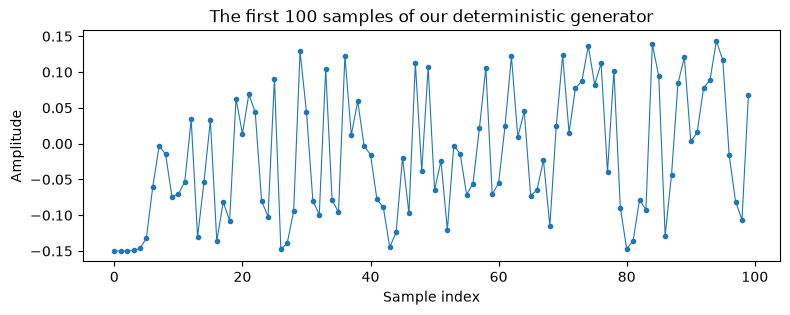

In [20]:
noise_samples = []
x = 0
for _ in range(sample_rate):
    x = (5 * x + 1) % 65_536
    value = 0.15 * (2 * x / 65_535 - 1)
    noise_samples.append(value)

plt.figure(figsize=(9, 3))
plt.plot(noise_samples[:100], marker=".", linewidth=0.8)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("The first 100 samples of our deterministic generator")
plt.show()

In [21]:
Audio(noise_samples, rate=sample_rate, normalize=False)

The samples look irregular at this scale, but the rule still has structure and repeats. Treat this as a **toy pseudorandom generator**, not a model of ideal white noise.

Also, a centred amplitude range does not guarantee that every short excerpt has exactly zero mean.

### Your turn · Follow the state

1. Explain the first two loop iterations, including what `append` changes.
2. Change the initial `x` and compare the first ten values.
3. Restore it and run the cell again. Do you recover the same sequence?

## 8. Give noise a reusable recipe

As with the oscillator, we want to choose a duration and get a list of samples back. A `seed` supplies the initial state.

Each call starts from its seed. Equal seeds produce the same sequence; shorter calls produce prefixes of longer calls with the same seed and amplitude.

In [22]:
def noise(duration=1, amplitude=0.15, seed=0, sample_rate=48_000):
    wave = []
    x = seed
    for _ in range(round(sample_rate * duration)):
        x = (5 * x + 1) % 65_536
        wave.append(amplitude * (2 * x / 65_535 - 1))
    return wave

Audio(noise(duration=0.1), rate=sample_rate, normalize=False)

Short bursts separated by silence already suggest a rhythmic sound. At this point, every repeated hit is exactly the same sample data.

In [23]:
hit = noise(duration=0.05)
pulse = hit + silence(0.20)
Audio(pulse * 8, rate=sample_rate, normalize=False)

### Optional · Let the hit decay

A percussion sound often loses amplitude over time. We can multiply successive samples by a decreasing factor. This sequence of gains is an **envelope**.

The comprehension below starts near full gain and falls to zero. `max` keeps the denominator at least one, including for a one-sample hit.

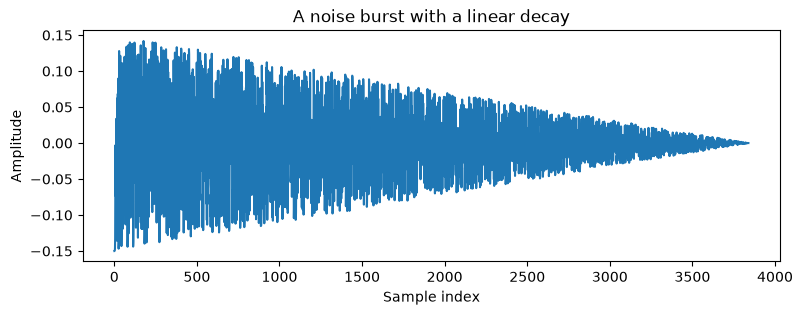

In [24]:
def percussion(duration=0.08, amplitude=0.15, seed=0, sample_rate=48_000):
    samples = noise(
        duration=duration, amplitude=amplitude, seed=seed,
        sample_rate=sample_rate,
    )
    denominator = max(1, len(samples) - 1)
    return [
        samples[n] * (1 - n / denominator)
        for n in range(len(samples))
    ]

decaying_hit = percussion()
plt.figure(figsize=(9, 3))
plt.plot(decaying_hit)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("A noise burst with a linear decay")
plt.show()

Audio(
    (decaying_hit + silence(0.17)) * 8,
    rate=sample_rate,
    normalize=False,
)

### Your turn · A rhythmic answer

Build a short rhythmic answer to the melody using noise hits and silence.

- Keep each rhythmic slot the same total length.
- Compare the raw burst and the decaying version.
- Try different seeds, then reuse one hit to make an exactly repeated pattern.

Listen to your melody followed by the rhythm. Putting their sample lists together sequences them in time. Playing both simultaneously would require sample-by-sample mixing, which is a different operation and a future step.

## What can we say now?

We began with a repeated list. Now we can describe a note by its pitch and duration, organise a melody as data, and ask for a noise burst or a decaying hit.

Each function gives a name to a computation and returns samples that other code can use. That common representation is what lets our small tools compose.

Keep your melody, one rhythmic experiment, and a sentence explaining which detail each function lets you stop repeating.